# 05. Аудит proxy-сигнала `Q_B2` разрешёнными признаками — V1

## Главный исследовательский вопрос

**Какую часть диагностического сигнала закрытого индекса `Q_B2_norm` можно воспроизвести только из 47 разрешённых признаков, и какие из них являются наиболее устойчивыми proxy для этого сигнала?**

### Почему этот вопрос идёт после Stage 4

Stage 4 V2 показал две разные вещи:

- `Q_B1_norm` сильнее как общий standalone predictor;
- `Q_B2_norm` лучше видит именно общую blind spot baseline.

Но `Q_B2_norm` нельзя использовать в финальной рабочей модели. Поэтому прежде чем придумывать новый feature engineering вслепую, нужно понять:

1. какая часть `Q_B2` уже содержится в разрешённых признаках;
2. какие признаки её несут;
3. остаётся ли существенный остаточный информационный gap, который потребует новых внешних данных.

### Контролируемый эксперимент

Не меняются:

- dataset и его SHA-256;
- working/final partition;
- 47 разрешённых признаков;
- Stage 3 OOF checkpoint и определение blind spot;
- final test остаётся закрытым;
- `Q_B2_norm` используется только как **diagnostic target/reference**, а не production feature.

Меняется только исследовательская задача:

- обучаем **один фиксированный CatBoost surrogate** восстанавливать порядковый risk-level `Q_B2` по 47 разрешённым признакам;
- получаем только OOF-предсказания;
- никакого Optuna, tuning, threshold optimization или выбора по final test;
- оцениваем reconstruction и отдельно качество proxy именно в Stage 3 blind spot;
- анализируем устойчивые surrogate importances по фолдам.

### Важное ограничение

Высокая surrogate importance означает только связь разрешённого признака с поведением `Q_B2`. Это **не причинность** и не доказательство того, что этот признак нужно автоматически усиливать в production-модели.


In [1]:
from __future__ import annotations

import hashlib
import importlib.metadata as importlib_metadata
import json
import platform
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from IPython.display import display
from sklearn.metrics import (
    average_precision_score,
    mean_absolute_error,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split


def найти_корень_проекта(начало: Path | None = None) -> Path:
    """Находит корень проекта по pyproject.toml."""
    текущая = (начало or Path.cwd()).resolve()
    for кандидат in [текущая, *текущая.parents]:
        if (кандидат / "pyproject.toml").exists():
            return кандидат
    raise FileNotFoundError("Не найден корень проекта с pyproject.toml.")


def вычислить_sha256(путь: Path, размер_блока: int = 1024 * 1024) -> str:
    """Вычисляет SHA-256 файла блоками."""
    хэш = hashlib.sha256()
    with путь.open("rb") as файл:
        for блок in iter(lambda: файл.read(размер_блока), b""):
            хэш.update(блок)
    return хэш.hexdigest()


def хэш_массива(значения: np.ndarray) -> str:
    """Вычисляет SHA-256 массива индексов."""
    массив = np.asarray(значения, dtype=np.int64)
    return hashlib.sha256(массив.tobytes()).hexdigest()


КОРЕНЬ_ПРОЕКТА = найти_корень_проекта()
ПУТЬ_ДАТАСЕТ = КОРЕНЬ_ПРОЕКТА / "data" / "raw" / "Data_final.xlsb"
ПАПКА_GENERATED = КОРЕНЬ_ПРОЕКТА / "reports" / "generated"
ПАПКА_SUMMARY = КОРЕНЬ_ПРОЕКТА / "reports" / "summary"
ПУТЬ_OOF_STAGE3 = ПАПКА_GENERATED / "stage3_oof_predictions_V1.npz"
ПУТЬ_SUMMARY_STAGE4 = ПАПКА_SUMMARY / "stage4_closed_signal_summary_V2.json"

ПАПКА_GENERATED.mkdir(parents=True, exist_ok=True)
ПАПКА_SUMMARY.mkdir(parents=True, exist_ok=True)

ОЖИДАЕМЫЙ_SHA_DATASET = "fc742be66d238c529daba52ccc755f774f836b7d052ed062cdf0b345080e7930"
ОЖИДАЕМЫЙ_SHA_РАБОТА = "80430ce6290d0982d3641621ba1ed62f6fb495e8d32f7d23d9fca00091aadb45"
ОЖИДАЕМЫЙ_SHA_TEST = "35ec963fe82918841f4a8acb012e8fc878aed66d2c5296ea6cb105177cafbb37"
ОЖИДАЕМЫЙ_SHA_OOF = "faa53a8aed86c2d445699c0fd1df6a5b83711c96d3a300f9a8860112ff4473ac"

ЦЕЛЬ = "DefMark"
ЗАКРЫТЫЙ_ИНДЕКС = "Q_B2_norm"

ДОПУСТИМЫЕ_ПРИЗНАКИ = [
    "Q_A1_norm", "Q_A2_norm", "Q_A3_norm", "Q_A4_norm",
    "Q_A5_norm", "Q_A6_norm", "Q_A7_norm",
    "Q_B3_norm", "Q_B4_norm", "Q_B5_norm",
    "Q_C1_norm",
    "Q_D1_norm", "Q_D2_norm", "Q_D3_norm", "Q_D4_norm",
    "Q_D5_norm", "Q_D6_norm",
    "A1_norm", "A2_norm", "A3_norm", "A4_norm", "A5_norm",
    "A6_norm",
    "B1_norm", "B2_norm", "B3_norm",
    "C1_norm", "C2_norm", "C3_norm", "C4_norm",
    "D1_norm", "D2_norm", "D3_norm", "D4_norm", "D5_norm",
    "E1_norm", "E2_norm", "E3_norm",
    "F1_norm", "F2_norm", "F3_norm", "F4_norm",
    "G1_norm", "G2_norm", "G3_norm", "G4_norm", "G5_norm",
]

ДОЛЯ_FINAL_TEST = 0.20
SEED = 42
ЧИСЛО_ФОЛДОВ = 3

ГРАНИЦА_ГЛУБОКОГО_ПРОПУСКА = 0.50
МАКС_РАЗБРОС_BLIND_SPOT = 0.10

CATBOOST_SURROGATE = {
    "iterations": 600,
    "depth": 6,
    "learning_rate": 0.05,
    "loss_function": "RMSE",
    "random_seed": SEED,
    "thread_count": -1,
    "verbose": False,
    "allow_writing_files": False,
}

ЁМКОСТИ = [0.10, 0.20, 0.30]

# Это не статистические significance thresholds, а заранее заданная
# рабочая эвристика для выбора следующего направления исследования.
ПОРОГ_БЛИЗКОГО_AUC = 0.03
ПОРОГ_БЛИЗКОГО_RESCUE_PP = 5.0
ПОРОГ_БОЛЬШОГО_AUC_GAP = 0.05
ПОРОГ_БОЛЬШОГО_RESCUE_GAP_PP = 10.0

print("Корень проекта:", КОРЕНЬ_ПРОЕКТА)
print("Python:", platform.python_version())
print("Разрешённых признаков:", len(ДОПУСТИМЫЕ_ПРИЗНАКИ))
print("Surrogate:", CATBOOST_SURROGATE)

Корень проекта: D:\Projects\komus-credit-risk
Python: 3.12.2
Разрешённых признаков: 47
Surrogate: {'iterations': 600, 'depth': 6, 'learning_rate': 0.05, 'loss_function': 'RMSE', 'random_seed': 42, 'thread_count': -1, 'verbose': False, 'allow_writing_files': False}


# 1. Gate идентичности данных и Stage 3/4

## Исследовательский вопрос

Работаем ли мы с тем же dataset, split, OOF checkpoint и принятым Stage 4 V2?

Если любой gate не проходит, дальнейший расчёт останавливается.


In [2]:
for путь in [ПУТЬ_ДАТАСЕТ, ПУТЬ_OOF_STAGE3, ПУТЬ_SUMMARY_STAGE4]:
    if not путь.exists():
        raise FileNotFoundError(f"Не найден обязательный файл: {путь}")

sha_dataset = вычислить_sha256(ПУТЬ_ДАТАСЕТ)
sha_oof = вычислить_sha256(ПУТЬ_OOF_STAGE3)

if sha_dataset.lower() != ОЖИДАЕМЫЙ_SHA_DATASET.lower():
    raise RuntimeError("SHA-256 dataset не совпал с принятым.")

if sha_oof.lower() != ОЖИДАЕМЫЙ_SHA_OOF.lower():
    raise RuntimeError("SHA-256 Stage 3 OOF checkpoint не совпал.")

with ПУТЬ_SUMMARY_STAGE4.open("r", encoding="utf-8") as файл:
    stage4 = json.load(файл)

if stage4.get("version") != "V2":
    raise RuntimeError("Ожидался Stage 4 V2 summary.")

if stage4.get("dataset_sha256", "").lower() != ОЖИДАЕМЫЙ_SHA_DATASET.lower():
    raise RuntimeError("Stage 4 использовал другой dataset.")

if stage4.get("stage3_oof_sha256", "").lower() != ОЖИДАЕМЫЙ_SHA_OOF.lower():
    raise RuntimeError("Stage 4 использовал другой Stage 3 OOF.")

if stage4.get("final_test_used") is not False:
    raise RuntimeError("Stage 4 summary сообщает использование final test.")

начало_чтения = perf_counter()

данные = pd.read_excel(
    ПУТЬ_ДАТАСЕТ,
    engine="pyxlsb",
    sheet_name="Data_final",
    usecols=[ЦЕЛЬ, ЗАКРЫТЫЙ_ИНДЕКС, *ДОПУСТИМЫЕ_ПРИЗНАКИ],
).reset_index(drop=True)

время_чтения = perf_counter() - начало_чтения

ожидаемые_столбцы = {ЦЕЛЬ, ЗАКРЫТЫЙ_ИНДЕКС, *ДОПУСТИМЫЕ_ПРИЗНАКИ}
отсутствующие = ожидаемые_столбцы.difference(данные.columns)

if отсутствующие:
    raise KeyError(f"Отсутствуют столбцы: {sorted(отсутствующие)}")

for столбец in данные.columns:
    данные[столбец] = pd.to_numeric(данные[столбец], errors="raise")

if данные[list(ожидаемые_столбцы)].isna().any().any():
    raise RuntimeError("В анализируемых столбцах обнаружены пропуски.")

индексы = np.arange(len(данные))

индексы_работа_контроль, индексы_test_контроль = train_test_split(
    индексы,
    test_size=ДОЛЯ_FINAL_TEST,
    stratify=данные[ЦЕЛЬ],
    random_state=SEED,
)

if хэш_массива(индексы_работа_контроль) != ОЖИДАЕМЫЙ_SHA_РАБОТА:
    raise RuntimeError("Working split не совпал.")

if хэш_массива(индексы_test_контроль) != ОЖИДАЕМЫЙ_SHA_TEST:
    raise RuntimeError("Final test split не совпал.")

with np.load(ПУТЬ_OOF_STAGE3) as checkpoint:
    working_indices = np.asarray(checkpoint["working_indices"], dtype=np.int64)
    target = np.asarray(checkpoint["target"], dtype=np.int8)
    consensus_rank = np.asarray(checkpoint["consensus_rank"], dtype=np.float64)
    rank_spread = np.asarray(checkpoint["rank_spread"], dtype=np.float64)

if not np.array_equal(working_indices, индексы_работа_контроль):
    raise RuntimeError("Порядок working_indices не совпал.")

target_dataset = данные.iloc[working_indices][ЦЕЛЬ].to_numpy(dtype=np.int8)

if not np.array_equal(target, target_dataset):
    raise RuntimeError("Target Stage 3 не совпал с dataset.")

маска_дефолт = target == 1
маска_недефолт = ~маска_дефолт
маска_глубокий_пропуск = маска_дефолт & (
    consensus_rank <= ГРАНИЦА_ГЛУБОКОГО_ПРОПУСКА
)
маска_blind_spot = маска_глубокий_пропуск & (
    rank_spread <= МАКС_РАЗБРОС_BLIND_SPOT
)

if int(маска_blind_spot.sum()) != 805:
    raise RuntimeError(
        f"Blind spot не воспроизвёлся: {маска_blind_spot.sum()} вместо 805."
    )

ПАСПОРТ = pd.DataFrame([
    ("SHA dataset", sha_dataset),
    ("SHA Stage 3 OOF", sha_oof),
    ("Строк dataset", len(данные)),
    ("Working rows", len(working_indices)),
    ("Final test rows", len(индексы_test_контроль)),
    ("Blind spot defaults", int(маска_blind_spot.sum())),
    ("Время чтения XLSB, сек", время_чтения),
], columns=["Проверка", "Значение"])

display(ПАСПОРТ)
print("Final test зафиксирован, но его значения не используются в эксперименте.")

,Проверка,Значение
0,SHA dataset,fc742be66d238c529daba52ccc755f774f836b7d052ed0...
1,SHA Stage 3 OOF,faa53a8aed86c2d445699c0fd1df6a5b83711c96d3a300...
2,Строк dataset,362018
3,Working rows,289614
4,Final test rows,72404
5,Blind spot defaults,805
6,"Время чтения XLSB, сек",136.549632


Final test зафиксирован, но его значения не используются в эксперименте.


# 2. Порядковая diagnostic target для `Q_B2`

## Исследовательский вопрос

Как представить дискретный Q_B2 в единой фиксированной шкале риска, сохранив заранее определённый порядок его уровней?

Stage 4 V2 уже зафиксировал ориентацию: меньше Q_B2_norm → выше наблюдаемый риск.

Поэтому шесть исходных значений преобразуются в уровни 0..5, где 5 — самый высокий diagnostic risk. Ориентация не выбирается повторно по DefMark.

Методологическое ограничение: CatBoostRegressor с RMSE трактует уровни 0..5 как числовую шкалу и тем самым вводит допущение о равных расстояниях между соседними уровнями. Поэтому основной критерий reconstruction — ранговый OOF Spearman, а MAE используется только как дополнительная диагностическая метрика. Этот experiment не является полноценной ordinal-regression моделью.

Stage 4 V2 уже зафиксировал ориентацию: **меньше `Q_B2_norm` → выше наблюдаемый риск**.

Поэтому шесть исходных значений преобразуются в уровни `0..5`, где `5` — самый высокий diagnostic risk. Ориентация не выбирается повторно по `DefMark`.


In [3]:
q_b2_work = (
    данные.iloc[working_indices][ЗАКРЫТЫЙ_ИНДЕКС]
    .to_numpy(dtype=np.float64)
)

уникальные_qb2 = np.sort(np.unique(q_b2_work))

if len(уникальные_qb2) != 6:
    raise RuntimeError(
        f"Ожидалось 6 значений Q_B2, получено {len(уникальные_qb2)}."
    )

# Самое маленькое исходное значение получает максимальный risk-level.
карта_risk_level = {
    float(значение): int(len(уникальные_qb2) - 1 - i)
    for i, значение in enumerate(уникальные_qb2)
}

q_b2_risk_level = np.asarray(
    [карта_risk_level[float(v)] for v in q_b2_work],
    dtype=np.float32,
)

ТАБЛИЦА_QB2 = (
    pd.DataFrame({
        "Q_B2_norm": q_b2_work,
        "Q_B2 risk-level": q_b2_risk_level.astype(int),
    })
    .value_counts()
    .rename("Число строк")
    .reset_index()
    .sort_values("Q_B2 risk-level", ascending=False)
)

display(ТАБЛИЦА_QB2)

print("Карта Q_B2 -> risk-level:")
for raw, level in sorted(
    карта_risk_level.items(),
    key=lambda x: x[1],
    reverse=True,
):
    print(f"  {raw:>10.4f} -> {level}")

,Q_B2_norm,Q_B2 risk-level,Число строк
3,-210.2249,5,13659
4,-46.6927,4,9494
5,-26.4613,3,5302
2,-15.3630,2,19362
1,-9.1520,1,45587
0,21.2192,0,196210


Карта Q_B2 -> risk-level:
   -210.2249 -> 5
    -46.6927 -> 4
    -26.4613 -> 3
    -15.3630 -> 2
     -9.1520 -> 1
     21.2192 -> 0


# 3. OOF surrogate: можно ли восстановить `Q_B2` из 47 разрешённых признаков?

## Исследовательский вопрос

Насколько хорошо один фиксированный нелинейный surrogate восстанавливает ordinal risk-level `Q_B2` на строках, которых он не видел при обучении?

### Почему CatBoostRegressor

Здесь CatBoost не соревнуется с baseline-моделями и не объявляется production-кандидатом. Он используется как один достаточно сильный нелинейный диагностический инструмент.

### Fold design

Это **другая prediction task**, поэтому её OOF нельзя сравнивать с Gini Stage 1 как качество модели дефолта.

Для устойчивости folds стратифицируются по совместной комбинации:

- `DefMark`;
- `Q_B2 risk-level`.

Параметры surrogate фиксированы заранее, tuning отсутствует.

Ограничение fold design

DefMark используется только при построении совместной стратификации folds вместе с Q_B2 risk-level; он не передаётся surrogate как признак.

Это помогает сохранить сопоставимое представительство дефолтов и уровней Q_B2 в каждом fold, но является особенностью evaluation design: разбиение использует известный outcome для формирования folds и не имитирует будущий deployment-сценарий.

Поэтому данный Stage доказывает диагностическую reconstructability Q_B2 в зафиксированном OOF-протоколе, но не доказывает temporal/deployment stability.


In [4]:
X_work = (
    данные.iloc[working_indices][ДОПУСТИМЫЕ_ПРИЗНАКИ]
    .astype("float32")
    .reset_index(drop=True)
)

y_default_work = target.astype(np.int8)
y_qb2_work = q_b2_risk_level.astype(np.float32)

страта = np.asarray([
    f"{int(d)}_{int(q)}"
    for d, q in zip(y_default_work, y_qb2_work)
])

минимальная_страта = int(pd.Series(страта).value_counts().min())

if минимальная_страта < ЧИСЛО_ФОЛДОВ:
    raise RuntimeError(
        "Недостаточно наблюдений в одной из совместных strata."
    )

cv = StratifiedKFold(
    n_splits=ЧИСЛО_ФОЛДОВ,
    shuffle=True,
    random_state=SEED,
)

oof_qb2_proxy = np.full(len(X_work), np.nan, dtype=np.float64)
важности_фолдов = []
время_фолдов = []

for fold, (train_idx, valid_idx) in enumerate(
    cv.split(X_work, страта),
    start=1,
):
    print(
        f"Fold {fold}/{ЧИСЛО_ФОЛДОВ}: "
        f"train={len(train_idx):,}, valid={len(valid_idx):,}"
    )

    модель = CatBoostRegressor(**CATBOOST_SURROGATE)

    начало = perf_counter()
    модель.fit(
        X_work.iloc[train_idx],
        y_qb2_work[train_idx],
    )
    время = perf_counter() - начало

    oof_qb2_proxy[valid_idx] = модель.predict(
        X_work.iloc[valid_idx]
    )

    важность = модель.get_feature_importance(
        type="PredictionValuesChange"
    )

    важности_фолдов.append(
        pd.DataFrame({
            "Признак": ДОПУСТИМЫЕ_ПРИЗНАКИ,
            "Fold": fold,
            "Surrogate importance": важность,
        })
    )

    время_фолдов.append({
        "Fold": fold,
        "Время обучения, сек": время,
    })

    print(f"✓ Fold {fold}: {время:.1f} сек")

if np.isnan(oof_qb2_proxy).any():
    raise RuntimeError("Не все строки получили OOF proxy prediction.")

ТАБЛИЦА_ВРЕМЕНИ = pd.DataFrame(время_фолдов)
display(ТАБЛИЦА_ВРЕМЕНИ.round(2))

print(
    "Общее время OOF surrogate, сек:",
    round(float(ТАБЛИЦА_ВРЕМЕНИ["Время обучения, сек"].sum()), 2),
)

Fold 1/3: train=193,076, valid=96,538
✓ Fold 1: 13.3 сек
Fold 2/3: train=193,076, valid=96,538
✓ Fold 2: 13.9 сек
Fold 3/3: train=193,076, valid=96,538
✓ Fold 3: 14.8 сек


,Fold,"Время обучения, сек"
0,1,13.35
1,2,13.91
2,3,14.79


Общее время OOF surrogate, сек: 42.05


# 4. Насколько хорошо восстановлен `Q_B2`

## Исследовательский вопрос

Есть ли у 47 разрешённых признаков достаточно информации, чтобы воспроизводить ранжирование закрытого индекса на unseen строках?

Основная метрика — **OOF Spearman** между predicted proxy и ordinal risk-level `Q_B2`.

Дополнительно:

- MAE в единицах ordinal level;
- Spearman отдельно внутри 805 blind-spot дефолтов.

Эти метрики описывают reconstruction `Q_B2`, а не качество default-модели.


,Метрика,Значение
0,OOF Spearman: весь working,0.5421
1,OOF MAE ordinal level,0.7058
2,OOF Spearman: blind spot,0.0242


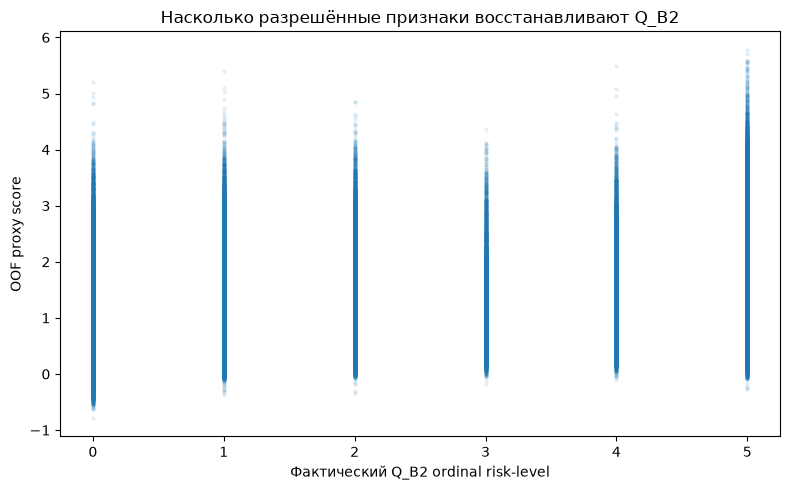

In [5]:
def безопасный_spearman(a: np.ndarray, b: np.ndarray) -> float:
    """Spearman через pandas с явной проверкой вариативности."""
    a = np.asarray(a)
    b = np.asarray(b)

    if len(np.unique(a)) < 2 or len(np.unique(b)) < 2:
        return float("nan")

    return float(
        pd.Series(a).corr(
            pd.Series(b),
            method="spearman",
        )
    )


spearman_all = безопасный_spearman(
    y_qb2_work,
    oof_qb2_proxy,
)
mae_all = float(
    mean_absolute_error(
        y_qb2_work,
        oof_qb2_proxy,
    )
)
spearman_blind = безопасный_spearman(
    y_qb2_work[маска_blind_spot],
    oof_qb2_proxy[маска_blind_spot],
)

ТАБЛИЦА_RECONSTRUCTION = pd.DataFrame([
    {
        "Метрика": "OOF Spearman: весь working",
        "Значение": spearman_all,
    },
    {
        "Метрика": "OOF MAE ordinal level",
        "Значение": mae_all,
    },
    {
        "Метрика": "OOF Spearman: blind spot",
        "Значение": spearman_blind,
    },
])

display(ТАБЛИЦА_RECONSTRUCTION.round(4))

plt.figure(figsize=(8, 5))
plt.scatter(
    y_qb2_work,
    oof_qb2_proxy,
    s=5,
    alpha=0.08,
)
plt.xlabel("Фактический Q_B2 ordinal risk-level")
plt.ylabel("OOF proxy score")
plt.title("Насколько разрешённые признаки восстанавливают Q_B2")
plt.tight_layout()
plt.show()

# 5. Видит ли OOF proxy ту же blind spot, что и настоящий `Q_B2`

## Исследовательский вопрос

Даже если proxy в среднем похож на `Q_B2`, сохраняет ли он полезный сигнал именно в критической группе Stage 3?

Сравниваем:

1. ROC-AUC `blind spot vs non-default`;
2. rescue blind-spot дефолтов при одинаковой фиксированной ёмкости 10/20/30%.

Для настоящего `Q_B2` берём уже принятую tie-aware оценку Stage 4 V2. Для OOF proxy используем тот же tie-aware принцип.


,Score,ROC-AUC blind spot vs non-default,PR-AUC
0,Q_B2 oracle,0.7234,0.2504
1,OOF Q_B2 proxy из 47 разрешённых признаков,0.3981,0.0023


,"Ёмкость, %","Q_B2 oracle expected rescue, %","OOF proxy expected rescue, %","Gap oracle - proxy, п.п.","Proxy min rescue, %","Proxy max rescue, %"
0,10.0,43.49,0.00,43.49,0.00,0.00
1,20.0,51.38,2.73,48.65,2.73,2.73
2,30.0,59.43,10.43,49.00,10.43,10.43


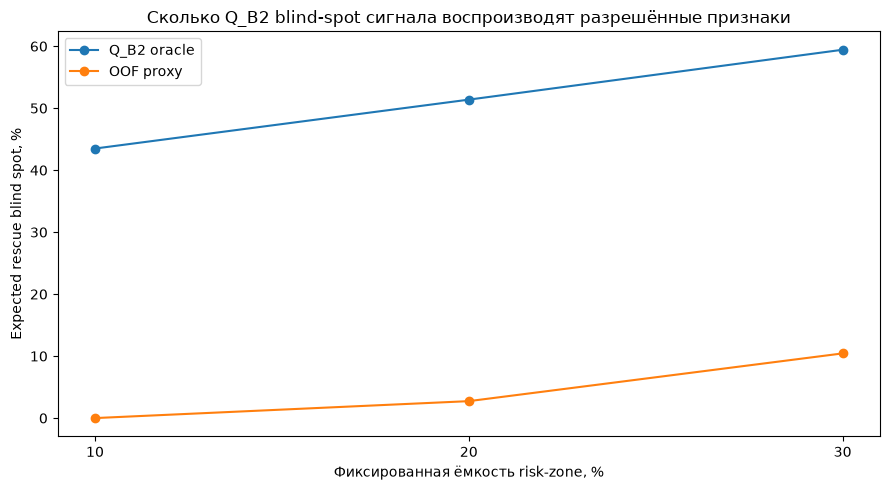

In [6]:
def tie_aware_rescue(
    score: np.ndarray,
    positive_mask: np.ndarray,
    capacity: float,
) -> dict[str, float | int]:
    """Expected/min/max rescue positives при фиксированной ёмкости."""
    score = np.asarray(score, dtype=np.float64)
    positive_mask = np.asarray(positive_mask, dtype=bool)

    n = len(score)
    k = int(round(capacity * n))
    total_positive = int(positive_mask.sum())

    таблица = pd.DataFrame({
        "score": score,
        "positive": positive_mask.astype(int),
    })

    группы = (
        таблица
        .groupby("score", as_index=False)
        .agg(
            rows=("positive", "size"),
            positives=("positive", "sum"),
        )
        .sort_values("score", ascending=False)
        .reset_index(drop=True)
    )

    remaining = k
    expected_positive = 0.0
    min_positive = 0.0
    max_positive = 0.0

    for row in группы.itertuples(index=False):
        group_rows = int(row.rows)
        group_positive = int(row.positives)
        group_negative = group_rows - group_positive

        if remaining <= 0:
            break

        if remaining >= group_rows:
            expected_positive += group_positive
            min_positive += group_positive
            max_positive += group_positive
            remaining -= group_rows
            continue

        fraction = remaining / group_rows
        expected_positive += fraction * group_positive
        min_positive += max(0, remaining - group_negative)
        max_positive += min(remaining, group_positive)
        remaining = 0

    if remaining != 0:
        raise RuntimeError("Не удалось заполнить фиксированную ёмкость.")

    return {
        "selected_rows": int(k),
        "expected_rescue_pct": float(
            expected_positive / total_positive * 100
        ),
        "min_rescue_pct": float(
            min_positive / total_positive * 100
        ),
        "max_rescue_pct": float(
            max_positive / total_positive * 100
        ),
    }


маска_blind_vs_nondefault = маска_blind_spot | маска_недефолт
y_blind_vs_nondefault = (
    маска_blind_spot[маска_blind_vs_nondefault]
    .astype(int)
)

proxy_blind_auc = float(
    roc_auc_score(
        y_blind_vs_nondefault,
        oof_qb2_proxy[маска_blind_vs_nondefault],
    )
)
proxy_blind_pr_auc = float(
    average_precision_score(
        y_blind_vs_nondefault,
        oof_qb2_proxy[маска_blind_vs_nondefault],
    )
)

строка_qb2_stage4 = next(
    row
    for row in stage4["blind_spot_vs_nondefault"]
    if row["Диагностический score"] == "Q_B2_norm"
)

oracle_blind_auc = float(
    строка_qb2_stage4["ROC-AUC blind spot vs non-default"]
)

oracle_rescue = {
    float(row["Ёмкость, %"]): float(row["Expected rescue, %"])
    for row in stage4["fixed_capacity_rescue"]
    if row["Индекс"] == "Q_B2_norm"
}

строки_сравнения_rescue = []

for capacity in ЁМКОСТИ:
    proxy_stats = tie_aware_rescue(
        score=oof_qb2_proxy,
        positive_mask=маска_blind_spot,
        capacity=capacity,
    )

    capacity_pct = capacity * 100
    oracle_value = oracle_rescue[capacity_pct]
    proxy_value = proxy_stats["expected_rescue_pct"]

    строки_сравнения_rescue.append({
        "Ёмкость, %": capacity_pct,
        "Q_B2 oracle expected rescue, %": oracle_value,
        "OOF proxy expected rescue, %": proxy_value,
        "Gap oracle - proxy, п.п.": oracle_value - proxy_value,
        "Proxy min rescue, %": proxy_stats["min_rescue_pct"],
        "Proxy max rescue, %": proxy_stats["max_rescue_pct"],
    })

ТАБЛИЦА_RESCUE = pd.DataFrame(строки_сравнения_rescue)

ТАБЛИЦА_BLIND_AUC = pd.DataFrame([
    {
        "Score": "Q_B2 oracle",
        "ROC-AUC blind spot vs non-default": oracle_blind_auc,
        "PR-AUC": float(
            строка_qb2_stage4["PR-AUC"]
        ),
    },
    {
        "Score": "OOF Q_B2 proxy из 47 разрешённых признаков",
        "ROC-AUC blind spot vs non-default": proxy_blind_auc,
        "PR-AUC": proxy_blind_pr_auc,
    },
])

display(ТАБЛИЦА_BLIND_AUC.round(4))
display(ТАБЛИЦА_RESCUE.round(2))

plt.figure(figsize=(9, 5))
plt.plot(
    ТАБЛИЦА_RESCUE["Ёмкость, %"],
    ТАБЛИЦА_RESCUE["Q_B2 oracle expected rescue, %"],
    marker="o",
    label="Q_B2 oracle",
)
plt.plot(
    ТАБЛИЦА_RESCUE["Ёмкость, %"],
    ТАБЛИЦА_RESCUE["OOF proxy expected rescue, %"],
    marker="o",
    label="OOF proxy",
)
plt.xlabel("Фиксированная ёмкость risk-zone, %")
plt.ylabel("Expected rescue blind spot, %")
plt.title("Сколько Q_B2 blind-spot сигнала воспроизводят разрешённые признаки")
plt.xticks([10, 20, 30])
plt.legend()
plt.tight_layout()
plt.show()

# 6. Какие разрешённые признаки несут proxy-сигнал `Q_B2`

## Исследовательский вопрос

Какие признаки surrogate использует наиболее устойчиво и есть ли у них подтверждённый бизнес-смысл?

Сопоставляем две независимые диагностические величины:

- среднюю CatBoost `PredictionValuesChange` importance по 3 folds;
- абсолютный univariate Spearman признака с ordinal `Q_B2 risk-level`.

Если признак важен только в одной из двух диагностик, это повод для осторожности, а не для автоматического feature engineering.


,Признак,Importance mean,Importance std,Mean rank,Rank std,Spearman с Q_B2 risk-level,|Spearman|,Расшифровка
0,Q_A5_norm,26.5841,0.2286,1.0000,0.0000,-0.4438,0.4438,Численность сотрудников
1,Q_D6_norm,13.8105,0.0154,2.0000,0.0000,-0.0050,0.0050,Режим налогообложения
2,G1_norm,5.7944,0.4815,3.0000,0.0000,-0.1830,0.1830,Темп роста выручки
3,A4_norm,4.5331,0.0554,4.3333,0.5774,-0.2890,0.2890,Капитал и резервы + ДБП
4,B1_norm,4.4183,0.2771,4.6667,0.5774,-0.2563,0.2563,Внеоборотные активы / Активы
5,Q_A4_norm,3.8235,0.1077,6.3333,0.5774,-0.0511,0.0511,Отраслевая характеристика
6,Q_C1_norm,3.8028,0.1618,6.6667,0.5774,-0.2336,0.2336,Кредитная история
7,Q_B3_norm,3.0451,0.1584,8.0000,0.0000,-0.0862,0.0862,Количество активных исполнительных производств
8,Q_A1_norm,2.5948,0.1347,9.3333,0.5774,0.0022,0.0022,Регион регистрации
9,D1_norm,2.3223,0.1767,10.3333,1.5275,-0.1664,0.1664,EBIT / Активы


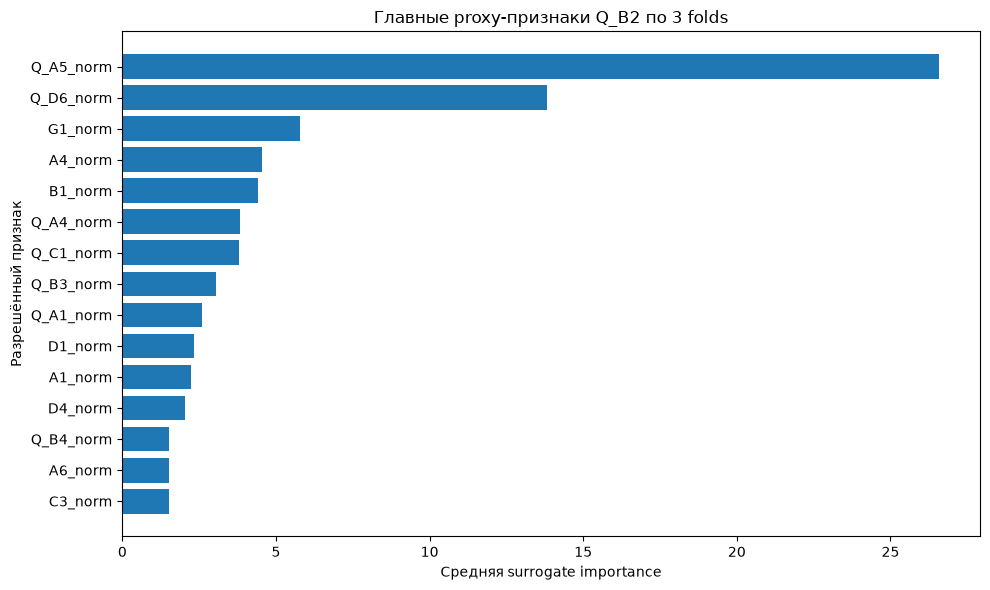

In [7]:
РАСШИФРОВКА = {
    "Q_A1_norm": "Регион регистрации",
    "Q_A4_norm": "Отраслевая характеристика",
    "Q_A5_norm": "Численность сотрудников",
    "Q_A6_norm": "Размер компании",
    "Q_B3_norm": "Количество активных исполнительных производств",
    "Q_C1_norm": "Кредитная история",
    "Q_D4_norm": "Компаний с аналогичным руководителем (по ИНН)",
    "Q_D6_norm": "Режим налогообложения",
    "A1_norm": "Собственный капитал / Активы",
    "A4_norm": "Капитал и резервы + ДБП",
    "B1_norm": "Внеоборотные активы / Активы",
    "B2_norm": "Долг / Активы",
    "D1_norm": "EBIT / Активы",
    "D5_norm": "Чистая прибыль / Выручка",
    "E1_norm": "Выручка / Дебиторская задолженность",
    "G1_norm": "Темп роста выручки",
    "G2_norm": "Темп роста чистых активов",
}

важности = pd.concat(
    важности_фолдов,
    ignore_index=True,
)

агрегат_важности = (
    важности
    .groupby("Признак", as_index=False)
    .agg(
        **{
            "Importance mean": (
                "Surrogate importance",
                "mean",
            ),
            "Importance std": (
                "Surrogate importance",
                "std",
            ),
        }
    )
)

ранги_фолдов = важности.copy()
ранги_фолдов["Ранг fold"] = (
    ранги_фолдов
    .groupby("Fold")["Surrogate importance"]
    .rank(method="average", ascending=False)
)

агрегат_рангов = (
    ранги_фолдов
    .groupby("Признак", as_index=False)
    .agg(
        **{
            "Mean rank": ("Ранг fold", "mean"),
            "Rank std": ("Ранг fold", "std"),
        }
    )
)

строки_spearman = []

for признак in ДОПУСТИМЫЕ_ПРИЗНАКИ:
    rho = безопасный_spearman(
        X_work[признак].to_numpy(),
        y_qb2_work,
    )
    строки_spearman.append({
        "Признак": признак,
        "Spearman с Q_B2 risk-level": rho,
        "|Spearman|": abs(rho),
    })

ТАБЛИЦА_PROXY_FEATURES = (
    агрегат_важности
    .merge(агрегат_рангов, on="Признак")
    .merge(pd.DataFrame(строки_spearman), on="Признак")
)

ТАБЛИЦА_PROXY_FEATURES["Расшифровка"] = (
    ТАБЛИЦА_PROXY_FEATURES["Признак"]
    .map(РАСШИФРОВКА)
    .fillna("Расшифровка не подтверждена в источниках")
)

ТАБЛИЦА_PROXY_FEATURES = (
    ТАБЛИЦА_PROXY_FEATURES
    .sort_values(
        ["Importance mean", "|Spearman|"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

display(
    ТАБЛИЦА_PROXY_FEATURES
    .head(20)
    .round(4)
)

топ15 = ТАБЛИЦА_PROXY_FEATURES.head(15).copy()

plt.figure(figsize=(10, 6))
plt.barh(
    топ15["Признак"][::-1],
    топ15["Importance mean"][::-1],
)
plt.xlabel("Средняя surrogate importance")
plt.ylabel("Разрешённый признак")
plt.title("Главные proxy-признаки Q_B2 по 3 folds")
plt.tight_layout()
plt.show()

# 7. Предзаданный критерий выбора следующего направления

Это **research heuristic**, а не statistical significance test.

Смотрим на два gap:

- `AUC gap` между настоящим `Q_B2` и OOF proxy в задаче `blind spot vs non-default`;
- `rescue gap` при фиксированной ёмкости 30%.

Интерпретация:

- **оба gap малы** (`AUC ≤ 0.03` и rescue ≤ 5 п.п.) → большая часть нужного `Q_B2`-сигнала уже присутствует в текущих признаках; следующий шаг — один targeted interaction/composite experiment среди устойчивых proxy;
- **хотя бы один gap большой** (`AUC ≥ 0.05` или rescue ≥ 10 п.п.) → в текущих 47 признаках остаётся материальный информационный пробел; приоритет — новый внешний feature block;
- между этими границами → частичное восстановление; сначала компактная feature hypothesis по топ-proxy, без ожидания полного закрытия gap.


In [8]:
auc_gap = float(oracle_blind_auc - proxy_blind_auc)

rescue_30_row = ТАБЛИЦА_RESCUE.loc[
    ТАБЛИЦА_RESCUE["Ёмкость, %"] == 30.0
].iloc[0]

rescue_gap_30 = float(
    rescue_30_row["Gap oracle - proxy, п.п."]
)

if (
    auc_gap <= ПОРОГ_БЛИЗКОГО_AUC
    and rescue_gap_30 <= ПОРОГ_БЛИЗКОГО_RESCUE_PP
):
    направление = (
        "Сигнал в основном восстанавливается текущими признаками. "
        "Следующий эксперимент: один прозрачный interaction/composite "
        "feature block из устойчивых top-proxy."
    )
    класс_вывода = "mostly_recoverable"
elif (
    auc_gap >= ПОРОГ_БОЛЬШОГО_AUC_GAP
    or rescue_gap_30 >= ПОРОГ_БОЛЬШОГО_RESCUE_GAP_PP
):
    направление = (
        "Остаётся материальный информационный gap. "
        "Следующий приоритет: один новый внешний feature block "
        "по сигналам должной осмотрительности/негативным событиям."
    )
    класс_вывода = "material_missing_signal"
else:
    направление = (
        "Сигнал восстанавливается частично. "
        "Следующий эксперимент: компактная прозрачная feature hypothesis "
        "по top-proxy, одновременно фиксируя, что полного замещения Q_B2 "
        "она не доказывает."
    )
    класс_вывода = "partial_recoverability"

print("ФАКТЫ")
print("-" * 72)
print(f"OOF Spearman Q_B2 reconstruction: {spearman_all:.4f}")
print(f"OOF Spearman внутри blind spot:  {spearman_blind:.4f}")
print(
    "Blind spot vs non-default ROC-AUC: "
    f"oracle Q_B2={oracle_blind_auc:.4f}, "
    f"OOF proxy={proxy_blind_auc:.4f}, "
    f"gap={auc_gap:.4f}"
)
print(
    "Rescue @30% capacity: "
    f"oracle={rescue_30_row['Q_B2 oracle expected rescue, %']:.2f}%, "
    f"proxy={rescue_30_row['OOF proxy expected rescue, %']:.2f}%, "
    f"gap={rescue_gap_30:.2f} п.п."
)

print("\nИНТЕРПРЕТАЦИЯ")
print("-" * 72)
print(направление)

print("\nОГРАНИЧЕНИЯ")
print("-" * 72)
print("- Surrogate обучается воспроизводить Q_B2, а не DefMark.")
print("- Q_B2 остаётся закрытым diagnostic reference.")
print("- Importance описывает поведение surrogate, а не причинность.")
print("- Границы 0.03 / 5 п.п. / 0.05 / 10 п.п. — research heuristic.")
print("- Final test не использован.")
print("- Random split не доказывает temporal stability.")

print("\nNEXT STEP")
print("-" * 72)
print(направление)

ФАКТЫ
------------------------------------------------------------------------
OOF Spearman Q_B2 reconstruction: 0.5421
OOF Spearman внутри blind spot:  0.0242
Blind spot vs non-default ROC-AUC: oracle Q_B2=0.7234, OOF proxy=0.3981, gap=0.3253
Rescue @30% capacity: oracle=59.43%, proxy=10.43%, gap=49.00 п.п.

ИНТЕРПРЕТАЦИЯ
------------------------------------------------------------------------
Остаётся материальный информационный gap. Следующий приоритет: один новый внешний feature block по сигналам должной осмотрительности/негативным событиям.

ОГРАНИЧЕНИЯ
------------------------------------------------------------------------
- Surrogate обучается воспроизводить Q_B2, а не DefMark.
- Q_B2 остаётся закрытым diagnostic reference.
- Importance описывает поведение surrogate, а не причинность.
- Границы 0.03 / 5 п.п. / 0.05 / 10 п.п. — research heuristic.
- Final test не использован.
- Random split не доказывает temporal stability.

NEXT STEP
--------------------------------------------

# 8. Сохранение воспроизводимых артефактов

Сохраняем:

- aggregate JSON в `reports/generated/`;
- таблицу proxy importance в `reports/generated/`;
- локальный OOF proxy checkpoint для следующего controlled experiment;
- маленький tracked summary в `reports/summary/`.

В tracked summary нет `INN`, строковых значений `Q_B2` или final test.


In [9]:
ПУТЬ_JSON = (
    ПАПКА_GENERATED
    / "stage5_qb2_proxy_audit_V1.json"
)
ПУТЬ_IMPORTANCE = (
    ПАПКА_GENERATED
    / "stage5_qb2_proxy_importance_V1.csv"
)
ПУТЬ_OOF_PROXY = (
    ПАПКА_GENERATED
    / "stage5_qb2_proxy_oof_V1.npz"
)
ПУТЬ_SUMMARY = (
    ПАПКА_SUMMARY
    / "stage5_qb2_proxy_audit_summary_V1.json"
)

ТАБЛИЦА_PROXY_FEATURES.to_csv(
    ПУТЬ_IMPORTANCE,
    index=False,
    encoding="utf-8-sig",
)

np.savez_compressed(
    ПУТЬ_OOF_PROXY,
    working_indices=working_indices,
    oof_qb2_proxy=oof_qb2_proxy.astype(np.float32),
)

версии = {
    пакет: importlib_metadata.version(пакет)
    for пакет in [
        "numpy",
        "pandas",
        "scikit-learn",
        "catboost",
        "pyxlsb",
        "matplotlib",
    ]
}

топ_proxy = (
    ТАБЛИЦА_PROXY_FEATURES
    .head(15)[
        [
            "Признак",
            "Расшифровка",
            "Importance mean",
            "Importance std",
            "Mean rank",
            "Rank std",
            "Spearman с Q_B2 risk-level",
            "|Spearman|",
        ]
    ]
    .to_dict(orient="records")
)

результат = {
    "experiment": "Stage 5",
    "version": "V1",
    "status": "completed_pending_review",
    "question": (
        "Какую часть Q_B2-сигнала можно воспроизвести "
        "из 47 разрешённых признаков?"
    ),
    "dataset_sha256": sha_dataset,
    "stage3_oof_sha256": sha_oof,
    "stage4_version": stage4["version"],
    "final_test_used": False,
    "working_rows": int(len(working_indices)),
    "blind_spot_size": int(маска_blind_spot.sum()),
    "allowed_features_count": int(len(ДОПУСТИМЫЕ_ПРИЗНАКИ)),
    "surrogate": {
        "model": "CatBoostRegressor",
        "params": CATBOOST_SURROGATE,
        "folds": ЧИСЛО_ФОЛДОВ,
        "stratification": "DefMark x Q_B2 ordinal risk-level",
    },
    "q_b2_mapping": {
        str(k): int(v)
        for k, v in карта_risk_level.items()
    },
    "reconstruction": {
        "oof_spearman_all": spearman_all,
        "oof_mae_ordinal_level": mae_all,
        "oof_spearman_blind_spot": spearman_blind,
    },
    "blind_spot_vs_nondefault": {
        "oracle_q_b2_roc_auc": oracle_blind_auc,
        "proxy_roc_auc": proxy_blind_auc,
        "auc_gap": auc_gap,
        "proxy_pr_auc": proxy_blind_pr_auc,
    },
    "fixed_capacity_rescue": (
        ТАБЛИЦА_RESCUE.to_dict(orient="records")
    ),
    "top_proxy_features": топ_proxy,
    "decision_class": класс_вывода,
    "decision": направление,
    "runtime_seconds": float(
        ТАБЛИЦА_ВРЕМЕНИ["Время обучения, сек"].sum()
    ),
    "library_versions": версии,
    "limitations": [
        "Surrogate предсказывает Q_B2, а не DefMark.",
        "Q_B2 используется только как diagnostic reference.",
        "Surrogate importance не доказывает причинность.",
        "Decision thresholds являются research heuristic.",
        "Final test не использован.",
        "Random split не доказывает temporal stability.",
    ],
}

with ПУТЬ_JSON.open("w", encoding="utf-8") as файл:
    json.dump(
        результат,
        файл,
        ensure_ascii=False,
        indent=2,
    )

summary = {
    "experiment": "Stage 5",
    "version": "V1",
    "status": "completed_pending_review",
    "question": результат["question"],
    "dataset_sha256": sha_dataset,
    "stage3_oof_sha256": sha_oof,
    "final_test_used": False,
    "working_rows": int(len(working_indices)),
    "blind_spot_size": int(маска_blind_spot.sum()),
    "oof_spearman_q_b2_reconstruction": spearman_all,
    "oof_spearman_blind_spot": spearman_blind,
    "oracle_q_b2_blind_auc": oracle_blind_auc,
    "proxy_blind_auc": proxy_blind_auc,
    "auc_gap": auc_gap,
    "rescue_at_30pct": {
        "oracle_q_b2_pct": float(
            rescue_30_row["Q_B2 oracle expected rescue, %"]
        ),
        "proxy_pct": float(
            rescue_30_row["OOF proxy expected rescue, %"]
        ),
        "gap_pp": rescue_gap_30,
    },
    "top_proxy_features": [
        {
            "feature": row["Признак"],
            "meaning": row["Расшифровка"],
            "importance_mean": float(row["Importance mean"]),
            "mean_rank": float(row["Mean rank"]),
            "spearman": float(
                row["Spearman с Q_B2 risk-level"]
            ),
        }
        for row in топ_proxy
    ],
    "decision_class": класс_вывода,
    "decision": направление,
}

with ПУТЬ_SUMMARY.open("w", encoding="utf-8") as файл:
    json.dump(
        summary,
        файл,
        ensure_ascii=False,
        indent=2,
    )

print("Сохранено:")
print("-", ПУТЬ_JSON)
print("-", ПУТЬ_IMPORTANCE)
print("-", ПУТЬ_OOF_PROXY)
print("-", ПУТЬ_SUMMARY)

Сохранено:
- D:\Projects\komus-credit-risk\reports\generated\stage5_qb2_proxy_audit_V1.json
- D:\Projects\komus-credit-risk\reports\generated\stage5_qb2_proxy_importance_V1.csv
- D:\Projects\komus-credit-risk\reports\generated\stage5_qb2_proxy_oof_V1.npz
- D:\Projects\komus-credit-risk\reports\summary\stage5_qb2_proxy_audit_summary_V1.json


# Итог Stage 5 V1 после review

## FACTS

На неизменном working sample из 289 614 строк и 47 разрешённых признаках получен OOF surrogate закрытого diagnostic reference `Q_B2_norm`.

Фактические результаты:

- OOF Spearman reconstruction на всём working sample: **0.5421**;
- OOF MAE ordinal level: **0.7058**;
- OOF Spearman внутри Stage 3 blind spot: **0.0242**;
- ROC-AUC в диагностике `blind spot vs non-default`:
  - настоящий `Q_B2`: **0.7234**;
  - OOF proxy: **0.3981**;
  - gap: **0.3253**;
- rescue при фиксированной ёмкости 30%:
  - настоящий `Q_B2`: **59.43%**;
  - OOF proxy: **10.43%**;
  - gap: **49.00 п.п.**

Surrogate устойчиво использует прежде всего `Q_A5_norm`, `Q_D6_norm`, `G1_norm`, `A4_norm`, `B1_norm`, `Q_A4_norm`, `Q_C1_norm` и `Q_B3_norm`.

Final test в эксперименте не использован.

## INTERPRETATION

47 разрешённых признаков действительно содержат часть общего сигнала `Q_B2`: умеренный OOF Spearman 0.5421 показывает, что закрытый индекс не является полностью независимым от текущего feature set.

Однако именно внутри общей blind spot Stage 3 эта воспроизводимость практически исчезает: Spearman снижается до 0.0242, а proxy сильно уступает настоящему `Q_B2` как по диагностическому ROC-AUC, так и по fixed-capacity rescue.

Следовательно, в рамках проверенного протокола существующие 47 признаков **не воспроизводят существенную часть того сигнала `Q_B2`, который полезен именно для текущей blind spot**.

Это поддерживает класс решения **material missing signal**.

## LIMITATIONS

- Surrogate обучается воспроизводить `Q_B2`, а не прогнозировать `DefMark`.
- `Q_B2` остаётся закрытым diagnostic reference и не становится разрешённым production-признаком.
- CatBoost importance и univariate Spearman показывают ассоциации с proxy-задачей, а не причинное влияние на дефолт.
- Кодирование уровней `0..5` вместе с `RMSE` вводит допущение о равных расстояниях между ordinal levels; основной вывод поэтому опирается прежде всего на ранговые и blind-spot diagnostics.
- `DefMark` используется при стратификации folds, но не подаётся surrogate как predictor; это особенность evaluation design и не является доказательством deployment/temporal stability.
- ROC-AUC proxy **0.3981** не следует интерпретировать как утверждение, что surrogate «в целом хуже случайного»: это результат конкретной заранее зафиксированной ориентации в задаче `blind spot vs non-default`. Ориентация не переворачивается постфактум по `DefMark`.
- Пороговые границы для `AUC gap` и `rescue gap` являются заранее заданной research heuristic, а не statistical significance test.
- Random split/OOF не доказывают temporal stability.
- Final test не использован.

## DECISION

Гипотеза о том, что полезную для Stage 3 blind spot часть сигнала `Q_B2` можно в достаточной степени восстановить комбинацией уже имеющихся 47 разрешённых признаков, **не подтверждена в текущем эксперименте**.

Stage 5 V1 принимается как диагностическое свидетельство сохраняющегося материального информационного gap.

Формальное закрытие: **Stage 5 V1 принят (`completed_accepted`)**; `decision_class = material_missing_signal`.

## NEXT STEP

Не усиливать текущие 47 признаков вслепую и не заниматься tuning surrogate.

Следующий исследовательский вопрос — проверить **один новый внешний feature block**, который может содержать отсутствующий сигнал о должной осмотрительности / негативных событиях.

Новый block должен проверяться отдельным controlled experiment против неизменного baseline и без использования final test для выбора признаков.